<a href="https://colab.research.google.com/github/MoSahil147/DeepFake-Detection-in-Online-Social-Network-OSN-Using-Advanced-Machine-Learning/blob/main/DeepFake_Detection_in_Online_Social_Network_(OSN)_Using_Advanced_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
import shutil
import subprocess
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
# Define base paths
base_path = "/content/drive/MyDrive/DeepFake Datasets"
celeb_base = os.path.join(base_path, "Celeb-DF-v2")

real_vids = os.path.join(celeb_base, "real", "videos")
fake_vids = os.path.join(celeb_base, "fake", "videos")
real_frames = os.path.join(celeb_base, "real", "frames")
fake_frames = os.path.join(celeb_base, "fake", "frames")

# Create folder structure
print("\n[INFO] Creating folder structure for Celeb-DF-v2...")
for path in [real_vids, fake_vids, real_frames, fake_frames]:
    os.makedirs(path, exist_ok=True)
    print(f"[OK] Folder ready: {path}")


[INFO] Creating folder structure for Celeb-DF-v2...
[OK] Folder ready: /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos
[OK] Folder ready: /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/fake/videos
[OK] Folder ready: /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames
[OK] Folder ready: /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/fake/frames


In [ ]:
# Unzip Celeb-DF-v2.zip
celeb_zip = os.path.join(base_path, "Celeb-DF-v2.zip")
extract_path = os.path.join(base_path, "Celeb_Extracted")

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)
os.makedirs(extract_path, exist_ok=True)

print("\n[INFO] Extracting Celeb-DF-v2.zip...")
with zipfile.ZipFile(celeb_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("[DONE] Extraction complete.")


[INFO] Extracting Celeb-DF-v2.zip...
[DONE] Extraction complete.


In [ ]:
# Move YouTube-real videos into a subfolder inside real/videos

import os
import shutil

# Define paths
base_path = "/content/drive/MyDrive/DeepFake Datasets"
source_folder = os.path.join(base_path, "Celeb_Extracted", "YouTube-real")
destination_folder = os.path.join(base_path, "Celeb-DF-v2", "real", "videos", "YouTube Real Videos")

# Ensure destination folder exists
os.makedirs(destination_folder, exist_ok=True)

# Collect .mp4 videos
video_files = []
for root, _, files in os.walk(source_folder):
    for file in files:
        if file.endswith(".mp4"):
            video_files.append(os.path.join(root, file))

print(f"\n[INFO] Found {len(video_files)} .mp4 videos in YouTube-real")

# Move videos to new destination
for idx, video_path in enumerate(sorted(video_files), start=1):
    filename = os.path.basename(video_path)
    destination_path = os.path.join(destination_folder, filename)

    try:
        shutil.move(video_path, destination_path)
        print(f"[{idx}/{len(video_files)}] Moved: {video_path} → {destination_path}")
    except Exception as e:
        print(f"[{idx}/{len(video_files)}] Failed to move {video_path}: {e}")


[INFO] Found 300 .mp4 videos in YouTube-real
[1/300] Moved: /content/drive/MyDrive/DeepFake Datasets/Celeb_Extracted/YouTube-real/00000.mp4 → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos/YouTube Real Videos/00000.mp4
[2/300] Moved: /content/drive/MyDrive/DeepFake Datasets/Celeb_Extracted/YouTube-real/00001.mp4 → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos/YouTube Real Videos/00001.mp4
[3/300] Moved: /content/drive/MyDrive/DeepFake Datasets/Celeb_Extracted/YouTube-real/00002.mp4 → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos/YouTube Real Videos/00002.mp4
[4/300] Moved: /content/drive/MyDrive/DeepFake Datasets/Celeb_Extracted/YouTube-real/00003.mp4 → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos/YouTube Real Videos/00003.mp4
[5/300] Moved: /content/drive/MyDrive/DeepFake Datasets/Celeb_Extracted/YouTube-real/00004.mp4 → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos/YouTube Real Videos/0000

In [ ]:
import os
import shutil
import subprocess
import random

# Define paths
base_path = "/content/drive/MyDrive/DeepFake Datasets"
video_folder = os.path.join(base_path, "Celeb-DF-v2", "real", "videos", "YouTube Real Videos")
frame_root = os.path.join(base_path, "Celeb-DF-v2", "real", "frames", "YouTube Real Frames")

# Ensure output root exists
os.makedirs(frame_root, exist_ok=True)

# List all videos
video_files = sorted([f for f in os.listdir(video_folder) if f.endswith(".mp4")])
print(f"\n[INFO] Found {len(video_files)} videos in YouTube Real Videos")

# Extract frames from each video
for idx, video in enumerate(video_files, start=1):
    video_path = os.path.join(video_folder, video)
    name_only = os.path.splitext(video)[0]
    frame_dir = os.path.join(frame_root, name_only)

    if os.path.exists(frame_dir):
        shutil.rmtree(frame_dir)
    os.makedirs(frame_dir, exist_ok=True)

    print(f"[{idx}/{len(video_files)}] Extracting frames from: {video}")

    result = subprocess.call([
        "ffmpeg", "-i", video_path,
        "-vf", "fps=3",  # Higher FPS to ensure more frames
        os.path.join(frame_dir, "frame_%04d.png"),
        "-hide_banner", "-loglevel", "error"
    ])

    if result == 0:
        frames = sorted([f for f in os.listdir(frame_dir) if f.endswith(".png")])
        total_frames = len(frames)

        # Keep between 10 to 20 frames, or all if fewer than 10
        if total_frames > 20:
            keep = random.randint(10, 20)
            for f in frames[keep:]:
                os.remove(os.path.join(frame_dir, f))
            print(f"[{idx}/{len(video_files)}] {keep} frames kept → {frame_dir}")
        else:
            print(f"[{idx}/{len(video_files)}] {total_frames} frames kept (all) → {frame_dir}")
    else:
        print(f"[{idx}/{len(video_files)}] Frame extraction failed for: {video_path}")


[INFO] Found 300 videos in YouTube Real Videos
[1/300] Extracting frames from: 00000.mp4
[1/300] 14 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/YouTube Real Frames/00000
[2/300] Extracting frames from: 00001.mp4
[2/300] 13 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/YouTube Real Frames/00001
[3/300] Extracting frames from: 00002.mp4
[3/300] 10 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/YouTube Real Frames/00002
[4/300] Extracting frames from: 00003.mp4
[4/300] 14 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/YouTube Real Frames/00003
[5/300] Extracting frames from: 00004.mp4
[5/300] 11 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/YouTube Real Frames/00004
[6/300] Extracting frames from: 00005.mp4
[6/300] 20 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/YouTube Real Frames/00005
[7/3

In [ ]:
# Move Celeb-real videos into a subfolder inside real/videos

import os
import shutil

# Define paths
base_path = "/content/drive/MyDrive/DeepFake Datasets"
source_folder = os.path.join(base_path, "Celeb_Extracted", "Celeb-real")
destination_folder = os.path.join(base_path, "Celeb-DF-v2", "real", "videos", "Celeb Real Videos")

# Ensure destination folder exists
os.makedirs(destination_folder, exist_ok=True)

# Collect .mp4 videos
video_files = []
for root, _, files in os.walk(source_folder):
    for file in files:
        if file.endswith(".mp4"):
            video_files.append(os.path.join(root, file))

print(f"\n[INFO] Found {len(video_files)} .mp4 videos in Celeb-real")

# Move videos to new destination
for idx, video_path in enumerate(sorted(video_files), start=1):
    filename = os.path.basename(video_path)
    destination_path = os.path.join(destination_folder, filename)

    try:
        shutil.move(video_path, destination_path)
        print(f"[{idx}/{len(video_files)}] Moved: {video_path} → {destination_path}")
    except Exception as e:
        print(f"[{idx}/{len(video_files)}] Failed to move {video_path}: {e}")


[INFO] Found 590 .mp4 videos in Celeb-real
[1/590] Moved: /content/drive/MyDrive/DeepFake Datasets/Celeb_Extracted/Celeb-real/id0_0000.mp4 → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos/Celeb Real Videos/id0_0000.mp4
[2/590] Moved: /content/drive/MyDrive/DeepFake Datasets/Celeb_Extracted/Celeb-real/id0_0001.mp4 → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos/Celeb Real Videos/id0_0001.mp4
[3/590] Moved: /content/drive/MyDrive/DeepFake Datasets/Celeb_Extracted/Celeb-real/id0_0002.mp4 → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos/Celeb Real Videos/id0_0002.mp4
[4/590] Moved: /content/drive/MyDrive/DeepFake Datasets/Celeb_Extracted/Celeb-real/id0_0003.mp4 → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos/Celeb Real Videos/id0_0003.mp4
[5/590] Moved: /content/drive/MyDrive/DeepFake Datasets/Celeb_Extracted/Celeb-real/id0_0004.mp4 → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/videos/Celeb Real Videos

In [ ]:
import os
import subprocess
import shutil
import random

# Define paths
base_path = "/content/drive/MyDrive/DeepFake Datasets"
video_folder = os.path.join(base_path, "Celeb-DF-v2", "real", "videos", "Celeb Real Videos")
frame_root = os.path.join(base_path, "Celeb-DF-v2", "real", "frames", "Celeb Real Frames")

# Ensure output root exists
os.makedirs(frame_root, exist_ok=True)

# List all videos
video_files = sorted([f for f in os.listdir(video_folder) if f.endswith(".mp4")])
print(f"\n[INFO] Found {len(video_files)} videos in Celeb Real Videos")

# Extract frames from each video
for idx, video in enumerate(video_files, start=1):
    video_path = os.path.join(video_folder, video)
    name_only = os.path.splitext(video)[0]
    frame_dir = os.path.join(frame_root, name_only)

    if os.path.exists(frame_dir):
        shutil.rmtree(frame_dir)
    os.makedirs(frame_dir, exist_ok=True)

    print(f"[{idx}/{len(video_files)}] Extracting frames from: {video}")

    result = subprocess.call([
        "ffmpeg", "-i", video_path,
        "-vf", "fps=3",
        os.path.join(frame_dir, "frame_%04d.png"),
        "-hide_banner", "-loglevel", "error"
    ])

    if result == 0:
        frames = sorted([f for f in os.listdir(frame_dir) if f.endswith(".png")])
        total_frames = len(frames)

        if total_frames > 20:
            keep = random.randint(10, 20)
            for f in frames[keep:]:
                os.remove(os.path.join(frame_dir, f))
            print(f"[{idx}/{len(video_files)}] {keep} frames kept → {frame_dir}")
        else:
            print(f"[{idx}/{len(video_files)}] {total_frames} frames kept (all) → {frame_dir}")
    else:
        print(f"[{idx}/{len(video_files)}] Frame extraction failed for: {video_path}")


[INFO] Found 590 videos in Celeb Real Videos
[1/590] Extracting frames from: id0_0000.mp4
[1/590] 18 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/Celeb Real Frames/id0_0000
[2/590] Extracting frames from: id0_0001.mp4
[2/590] 14 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/Celeb Real Frames/id0_0001
[3/590] Extracting frames from: id0_0002.mp4
[3/590] 18 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/Celeb Real Frames/id0_0002
[4/590] Extracting frames from: id0_0003.mp4
[4/590] 17 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/Celeb Real Frames/id0_0003
[5/590] Extracting frames from: id0_0004.mp4
[5/590] 10 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/Celeb Real Frames/id0_0004
[6/590] Extracting frames from: id0_0005.mp4
[6/590] 13 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/real/frames/Celeb Rea

In [ ]:
# Move Celeb-synthesis videos into fake/videos/Celeb Synthesis Videos

import os
import shutil

# Define paths
base_path = "/content/drive/MyDrive/DeepFake Datasets"
source_folder = os.path.join(base_path, "Celeb_Extracted", "Celeb-synthesis")
destination_folder = os.path.join(base_path, "Celeb-DF-v2", "fake", "videos", "Celeb Synthesis Videos")

# Ensure destination folder exists
os.makedirs(destination_folder, exist_ok=True)

# Collect .mp4 videos
video_files = []
for root, _, files in os.walk(source_folder):
    for file in files:
        if file.endswith(".mp4"):
            video_files.append(os.path.join(root, file))

print(f"\n[INFO] Found {len(video_files)} .mp4 videos in Celeb-synthesis")

# Move videos to new destination
for idx, video_path in enumerate(sorted(video_files), start=1):
    filename = os.path.basename(video_path)
    destination_path = os.path.join(destination_folder, filename)

    try:
        shutil.move(video_path, destination_path)
        print(f"[{idx}/{len(video_files)}] Moved: {video_path} → {destination_path}")
    except Exception as e:
        print(f"[{idx}/{len(video_files)}] Failed to move {video_path}: {e}")

In [ ]:
import os
import shutil
import subprocess
import random

# Define base paths
base_path = "/content/drive/MyDrive/DeepFake Datasets"
video_folder = os.path.join(base_path, "Celeb-DF-v2", "fake", "videos", "Celeb Synthesis Videos")
frame_root = os.path.join(base_path, "Celeb-DF-v2", "fake", "frames", "Celeb Synthesis Frames")

# Ensure output directory exists
os.makedirs(frame_root, exist_ok=True)

# List all .mp4 videos and pick 460 randomly
all_videos = [f for f in os.listdir(video_folder) if f.endswith(".mp4")]
random.shuffle(all_videos)
video_files = all_videos[:460]

print(f"\n[INFO] Selected 460 random videos from Celeb Synthesis Videos")

# Extract frames from each selected video
for idx, video in enumerate(video_files, 1):
    video_path = os.path.join(video_folder, video)
    name_only = os.path.splitext(video)[0]
    frame_dir = os.path.join(frame_root, name_only)

    if os.path.exists(frame_dir):
        shutil.rmtree(frame_dir)
    os.makedirs(frame_dir, exist_ok=True)

    print(f"[{idx}/{len(video_files)}] Extracting frames from: {video}")

    # Extract frames at 3 FPS
    result = subprocess.call([
        "ffmpeg", "-i", video_path,
        "-vf", "fps=3",
        os.path.join(frame_dir, "frame_%04d.png"),
        "-hide_banner", "-loglevel", "error"
    ])

    if result == 0:
        frames = sorted([f for f in os.listdir(frame_dir) if f.endswith(".png")])
        original_count = len(frames)

        if original_count >= 10:
            keep_count = random.randint(10, min(20, original_count))
            for f in frames[keep_count:]:
                os.remove(os.path.join(frame_dir, f))
            print(f"[{idx}/{len(video_files)}] {keep_count} frames kept → {frame_dir}")
        elif 1 <= original_count < 10:
            print(f"[{idx}/{len(video_files)}] {original_count} frames kept (under 10) → {frame_dir}")
        else:
            shutil.rmtree(frame_dir)
            print(f"[{idx}/{len(video_files)}] Skipped — no frames extracted")
    else:
        print(f"[{idx}/{len(video_files)}] Frame extraction failed: {video_path}")


[INFO] Selected 460 random videos from Celeb Synthesis Videos
[1/460] Extracting frames from: id31_id29_0002.mp4
[1/460] 10 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/fake/frames/Celeb Synthesis Frames/id31_id29_0002
[2/460] Extracting frames from: id3_id16_0008.mp4
[2/460] 18 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/fake/frames/Celeb Synthesis Frames/id3_id16_0008
[3/460] Extracting frames from: id20_id37_0002.mp4
[3/460] 19 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/fake/frames/Celeb Synthesis Frames/id20_id37_0002
[4/460] Extracting frames from: id35_id9_0006.mp4
[4/460] 11 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/fake/frames/Celeb Synthesis Frames/id35_id9_0006
[5/460] Extracting frames from: id21_id23_0005.mp4
[5/460] 16 frames kept → /content/drive/MyDrive/DeepFake Datasets/Celeb-DF-v2/fake/frames/Celeb Synthesis Frames/id21_id23_0005
[6/460] Extracting frames from: id40_id43_0007

In [ ]:
!mkdir -p "/content/drive/MyDrive/DeepFake Datasets/FaceForensics_Real"

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

target_path = "/content/drive/MyDrive/DeepFake Datasets/download.py"

script_code = '''#!/usr/bin/env python
""" Downloads FaceForensics++ and Deep Fake Detection public data release
Example usage:
    see -h or https://github.com/ondyari/FaceForensics
"""
# -*- coding: utf-8 -*-
import argparse
import os
import urllib
import urllib.request
import tempfile
import time
import sys
import json
import random
from tqdm import tqdm
from os.path import join

FILELIST_URL = 'misc/filelist.json'
DEEPFEAKES_DETECTION_URL = 'misc/deepfake_detection_filenames.json'
DEEPFAKES_MODEL_NAMES = ['decoder_A.h5', 'decoder_B.h5', 'encoder.h5',]

DATASETS = {
    'original_youtube_videos': 'misc/downloaded_youtube_videos.zip',
    'original_youtube_videos_info': 'misc/downloaded_youtube_videos_info.zip',
    'original': 'original_sequences/youtube',
    'DeepFakeDetection_original': 'original_sequences/actors',
    'Deepfakes': 'manipulated_sequences/Deepfakes',
    'DeepFakeDetection': 'manipulated_sequences/DeepFakeDetection',
    'Face2Face': 'manipulated_sequences/Face2Face',
    'FaceShifter': 'manipulated_sequences/FaceShifter',
    'FaceSwap': 'manipulated_sequences/FaceSwap',
    'NeuralTextures': 'manipulated_sequences/NeuralTextures'
}
ALL_DATASETS = list(DATASETS.keys())
COMPRESSION = ['raw', 'c23', 'c40']
TYPE = ['videos', 'masks', 'models']
SERVERS = ['EU', 'EU2', 'CA']

def parse_args():
    parser = argparse.ArgumentParser(description='Downloads FaceForensics v2 public data release.')
    parser.add_argument('output_path', type=str, help='Output directory.')
    parser.add_argument('-d', '--dataset', type=str, default='all', choices=ALL_DATASETS + ['all'])
    parser.add_argument('-c', '--compression', type=str, default='raw', choices=COMPRESSION)
    parser.add_argument('-t', '--type', type=str, default='videos', choices=TYPE)
    parser.add_argument('-n', '--num_videos', type=int, default=None)
    parser.add_argument('--server', type=str, default='EU', choices=SERVERS)
    args = parser.parse_args()

    if args.server == 'EU':
        server_url = 'http://canis.vc.in.tum.de:8100/'
    elif args.server == 'EU2':
        server_url = 'http://kaldir.vc.in.tum.de/faceforensics/'
    elif args.server == 'CA':
        server_url = 'http://falas.cmpt.sfu.ca:8100/'
    else:
        raise Exception('Wrong server name.')

    args.tos_url = server_url + 'webpage/FaceForensics_TOS.pdf'
    args.base_url = server_url + 'v3/'
    args.deepfakes_model_url = server_url + 'v3/manipulated_sequences/Deepfakes/models/'
    return args

def download_files(filenames, base_url, output_path, report_progress=True):
    os.makedirs(output_path, exist_ok=True)
    if report_progress:
        filenames = tqdm(filenames)
    for filename in filenames:
        download_file(base_url + filename, join(output_path, filename))

def reporthook(count, block_size, total_size):
    global start_time
    if count == 0:
        start_time = time.time()
        return
    duration = time.time() - start_time
    progress_size = int(count * block_size)
    speed = int(progress_size / (1024 * duration))
    percent = int(count * block_size * 100 / total_size)
    sys.stdout.write("\\rProgress: %d%%, %d MB, %d KB/s, %d seconds passed" %
                     (percent, progress_size / (1024 * 1024), speed, duration))
    sys.stdout.flush()

def download_file(url, out_file, report_progress=False):
    out_dir = os.path.dirname(out_file)
    if not os.path.isfile(out_file):
        fh, out_file_tmp = tempfile.mkstemp(dir=out_dir)
        f = os.fdopen(fh, 'w')
        f.close()
        if report_progress:
            urllib.request.urlretrieve(url, out_file_tmp, reporthook=reporthook)
        else:
            urllib.request.urlretrieve(url, out_file_tmp)
        os.rename(out_file_tmp, out_file)
    else:
        tqdm.write('WARNING: skipping existing file ' + out_file)

def main(args):
    print('By pressing any key to continue you confirm you have agreed to:')
    print(args.tos_url)
    print('*** Press any key to continue or CTRL-C to abort ***')
    _ = input()

    c_datasets = [args.dataset] if args.dataset != 'all' else ALL_DATASETS
    c_type = args.type
    c_compression = args.compression
    num_videos = args.num_videos
    output_path = args.output_path
    os.makedirs(output_path, exist_ok=True)

    for dataset in c_datasets:
        dataset_path = DATASETS[dataset]
        print(f'Downloading {c_type} from dataset "{dataset_path}"')

        if 'original_youtube_videos' in dataset:
            suffix = '' if 'info' not in dataset_path else 'info'
            download_file(args.base_url + '/' + dataset_path,
                          out_file=join(output_path, f'downloaded_videos{suffix}.zip'),
                          report_progress=True)
            return

        # Load filelist
        if 'DeepFakeDetection' in dataset_path or 'actors' in dataset_path:
            filepaths = json.loads(urllib.request.urlopen(args.base_url + '/' + DEEPFEAKES_DETECTION_URL).read().decode("utf-8"))
            filelist = filepaths['actors'] if 'actors' in dataset_path else filepaths['DeepFakesDetection']
        elif 'original' in dataset_path:
            file_pairs = json.loads(urllib.request.urlopen(args.base_url + '/' + FILELIST_URL).read().decode("utf-8"))
            filelist = sum(file_pairs, [])
        else:
            file_pairs = json.loads(urllib.request.urlopen(args.base_url + '/' + FILELIST_URL).read().decode("utf-8"))
            filelist = ['_'.join(p) for p in file_pairs]
            if c_type != 'models':
                filelist += ['_'.join(p[::-1]) for p in file_pairs]

        if num_videos:
            filelist = filelist[:num_videos]

        dataset_videos_url = args.base_url + f'{dataset_path}/{c_compression}/{c_type}/'
        dataset_output_path = join(output_path, dataset_path, c_compression, c_type)
        filelist = [f + '.mp4' for f in filelist]
        print(f'Output: {dataset_output_path}')
        download_files(filelist, dataset_videos_url, dataset_output_path)

if __name__ == "__main__":
    args = parse_args()
    main(args)
'''

# Write the script to the file inside Drive
with open(target_path, "w") as f:
    f.write(script_code)

print(f"[OK] Script successfully saved to: {target_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] Script successfully saved to: /content/drive/MyDrive/DeepFake Datasets/download.py


In [ ]:
%cd "/content/drive/MyDrive/DeepFake Datasets"

/content/drive/MyDrive/DeepFake Datasets


In [ ]:
!python download.py "/content/drive/MyDrive/DeepFake Datasets/FaceForensics_Real" \
--dataset original \
--compression c23 \
--type videos \
--server EU2 \
--num_videos 1000

By pressing any key to continue you confirm you have agreed to:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
*** Press any key to continue or CTRL-C to abort ***


In [ ]:
# Download All Fake Videos
!mkdir -p "/content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake"

# Save the script
target_path_fake = "/content/drive/MyDrive/DeepFake Datasets/download_fakes.py"

fake_script_code = '''#!/usr/bin/env python
# -*- coding: utf-8 -*-
import argparse
import os
import urllib.request
import tempfile
import time
import sys
import json
from tqdm import tqdm
from os.path import join

FILELIST_URL = 'misc/filelist.json'
FAKE_DATASETS = {
    'Deepfakes': 'manipulated_sequences/Deepfakes',
    'Face2Face': 'manipulated_sequences/Face2Face',
    'FaceSwap': 'manipulated_sequences/FaceSwap',
    'NeuralTextures': 'manipulated_sequences/NeuralTextures'
}
COMPRESSION = ['raw', 'c23', 'c40']
TYPE = ['videos']
SERVERS = ['EU', 'EU2', 'CA']

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('output_path', type=str)
    parser.add_argument('-c', '--compression', type=str, default='c23', choices=COMPRESSION)
    parser.add_argument('-t', '--type', type=str, default='videos', choices=TYPE)
    parser.add_argument('-n', '--num_videos', type=int, default=1000)
    parser.add_argument('--server', type=str, default='EU2', choices=SERVERS)
    return parser.parse_args()

def reporthook(count, block_size, total_size):
    global start_time
    if count == 0:
        start_time = time.time()
        return
    duration = time.time() - start_time
    progress = int(count * block_size)
    speed = int(progress / (1024 * duration))
    percent = int(count * block_size * 100 / total_size)
    sys.stdout.write(f"\\rProgress: {percent}%, {progress / (1024 * 1024):.2f} MB, {speed} KB/s, {int(duration)}s elapsed")
    sys.stdout.flush()

def download_file(url, out_file):
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    if not os.path.isfile(out_file):
        tmp_fd, tmp_path = tempfile.mkstemp(dir=os.path.dirname(out_file))
        os.close(tmp_fd)
        tqdm.write(f"[START] Downloading: {os.path.basename(out_file)}")
        urllib.request.urlretrieve(url, tmp_path, reporthook)
        os.rename(tmp_path, out_file)
        tqdm.write(f"[DONE]  Downloaded: {os.path.basename(out_file)}\\n")
    else:
        tqdm.write(f"[SKIPPED] Already exists: {os.path.basename(out_file)}")

def download_files(filelist, base_url, output_path):
    os.makedirs(output_path, exist_ok=True)
    for file in tqdm(filelist, desc=f"Downloading to {output_path}"):
        download_file(base_url + file + '.mp4', join(output_path, file + '.mp4'))

def main():
    args = parse_args()

    server_urls = {
        'EU': 'http://canis.vc.in.tum.de:8100/',
        'EU2': 'http://kaldir.vc.in.tum.de/faceforensics/',
        'CA': 'http://falas.cmpt.sfu.ca:8100/'
    }
    base_url = server_urls[args.server] + 'v3/'

    file_pairs = json.loads(urllib.request.urlopen(base_url + FILELIST_URL).read().decode("utf-8"))
    base_filelist = ['_'.join(p) for p in file_pairs] + ['_'.join(p[::-1]) for p in file_pairs]
    filelist = base_filelist[:args.num_videos]

    for dataset, path in FAKE_DATASETS.items():
        dataset_url = f"{base_url}{path}/{args.compression}/{args.type}/"
        dataset_out = join(args.output_path, path, args.compression, args.type)
        print(f"\\n[INFO] Downloading {len(filelist)} videos from {dataset}")
        download_files(filelist, dataset_url, dataset_out)

if __name__ == "__main__":
    main()
'''

# Write the script to file
with open(target_path_fake, "w") as f:
    f.write(fake_script_code)

print(f"[OK] Fake download script saved to: {target_path_fake}")

[OK] Fake download script saved to: /content/drive/MyDrive/DeepFake Datasets/download_fakes.py


In [ ]:
# Change to working directory
%cd "/content/drive/MyDrive/DeepFake Datasets"

# Run the script to download FAKE videos
!python download_fakes.py "/content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake" \
--compression c23 \
--type videos \
--server EU2 \
--num_videos 1000

/content/drive/MyDrive/DeepFake Datasets

[INFO] Downloading 1000 videos from Deepfakes
[SKIPPED] Already exists: 585_599.mp4
[SKIPPED] Already exists: 469_481.mp4
[SKIPPED] Already exists: 183_253.mp4
[SKIPPED] Already exists: 672_720.mp4
[SKIPPED] Already exists: 866_878.mp4
[SKIPPED] Already exists: 339_392.mp4
[SKIPPED] Already exists: 828_830.mp4
[SKIPPED] Already exists: 252_266.mp4
[SKIPPED] Already exists: 033_097.mp4
[SKIPPED] Already exists: 210_241.mp4
[SKIPPED] Already exists: 945_044.mp4
[SKIPPED] Already exists: 134_192.mp4
[SKIPPED] Already exists: 942_943.mp4
[SKIPPED] Already exists: 035_036.mp4
[SKIPPED] Already exists: 917_924.mp4
[SKIPPED] Already exists: 263_284.mp4
[SKIPPED] Already exists: 648_654.mp4
[SKIPPED] Already exists: 712_716.mp4
[SKIPPED] Already exists: 986_994.mp4
[SKIPPED] Already exists: 644_657.mp4
[SKIPPED] Already exists: 055_147.mp4
[SKIPPED] Already exists: 159_175.mp4
[SKIPPED] Already exists: 980_992.mp4
[SKIPPED] Already exists: 272_396.mp4


In [ ]:
import os

base_path = "/content/drive/MyDrive/DeepFake Datasets"

# FaceSwap
faceswap_folder = os.path.join(base_path, "FaceForensics_Fake", "manipulated_sequences", "FaceSwap", "c23", "videos")
faceswap_count = len([f for f in os.listdir(faceswap_folder) if f.endswith(".mp4")])
print(f"FaceSwap videos: {faceswap_count}")

# Deepfakes
deepfakes_folder = os.path.join(base_path, "FaceForensics_Fake", "manipulated_sequences", "Deepfakes", "c23", "videos")
deepfakes_count = len([f for f in os.listdir(deepfakes_folder) if f.endswith(".mp4")])
print(f"Deepfakes videos: {deepfakes_count}")

FaceSwap videos: 1000
Deepfakes videos: 1000


In [ ]:
import os, shutil, subprocess, random

base_path = "/content/drive/MyDrive/DeepFake Datasets"
video_folder = os.path.join(base_path, "FaceForensics_Fake", "manipulated_sequences", "FaceSwap", "c23", "videos")
frame_root = os.path.join(base_path, "FaceForensics_Fake", "frames", "FaceSwap")
os.makedirs(frame_root, exist_ok=True)

videos = [f for f in os.listdir(video_folder) if f.endswith(".mp4")]
random.shuffle(videos)
selected = videos[:1000]

print(f"\n[INFO] Extracting from 1000 FaceSwap videos")

for idx, video in enumerate(selected, 1):
    video_path = os.path.join(video_folder, video)
    out_dir = os.path.join(frame_root, os.path.splitext(video)[0])

    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

    subprocess.call([
        "ffmpeg", "-i", video_path, "-vf", "fps=3",
        os.path.join(out_dir, "frame_%04d.png"),
        "-hide_banner", "-loglevel", "error"
    ])

    frames = sorted([f for f in os.listdir(out_dir) if f.endswith(".png")])
    count = len(frames)

    keep = random.randint(10, min(20, count))
    for f in frames[keep:]:
        os.remove(os.path.join(out_dir, f))
    print(f"[{idx}/1000] {min(keep, count)} frames → {out_dir}")


[INFO] Extracting from 1000 FaceSwap videos
[1/1000] 11 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/FaceSwap/237_236
[2/1000] 19 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/FaceSwap/407_374
[3/1000] 20 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/FaceSwap/837_890
[4/1000] 12 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/FaceSwap/544_532
[5/1000] 13 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/FaceSwap/096_101
[6/1000] 14 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/FaceSwap/973_970
[7/1000] 14 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/FaceSwap/819_786
[8/1000] 12 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/FaceSwap/100_077
[9/1000] 10 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/FaceSwap/924_917
[10/1000] 

In [ ]:
import os, shutil, subprocess, random

base_path = "/content/drive/MyDrive/DeepFake Datasets"
video_folder = os.path.join(base_path, "FaceForensics_Fake", "manipulated_sequences", "Deepfakes", "c23", "videos")
frame_root = os.path.join(base_path, "FaceForensics_Fake", "frames", "Deepfakes")
os.makedirs(frame_root, exist_ok=True)

videos = [f for f in os.listdir(video_folder) if f.endswith(".mp4")]
random.shuffle(videos)
selected = videos[:890]

print(f"\n[INFO] Extracting from 890 Deepfakes videos")

for idx, video in enumerate(selected, 1):
    video_path = os.path.join(video_folder, video)
    out_dir = os.path.join(frame_root, os.path.splitext(video)[0])

    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

    subprocess.call([
        "ffmpeg", "-i", video_path, "-vf", "fps=3",
        os.path.join(out_dir, "frame_%04d.png"),
        "-hide_banner", "-loglevel", "error"
    ])

    frames = sorted([f for f in os.listdir(out_dir) if f.endswith(".png")])
    count = len(frames)

    keep = random.randint(10, min(20, count))
    for f in frames[keep:]:
        os.remove(os.path.join(out_dir, f))

    print(f"[{idx}/890] {min(keep, count)} frames → {out_dir}")


[INFO] Extracting from 890 Deepfakes videos
[1/890] 18 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Deepfakes/304_300
[2/890] 13 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Deepfakes/157_245
[3/890] 11 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Deepfakes/228_289
[4/890] 12 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Deepfakes/999_960
[5/890] 17 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Deepfakes/052_108
[6/890] 16 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Deepfakes/940_941
[7/890] 14 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Deepfakes/020_344
[8/890] 15 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Deepfakes/765_867
[9/890] 15 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Deepfakes/377_333
[10/890] 1

In [ ]:
import os, shutil, subprocess, random

base_path = "/content/drive/MyDrive/DeepFake Datasets"
video_folder = os.path.join(base_path, "FaceForensics_Fake", "manipulated_sequences", "Face2Face", "c23", "videos")
frame_root = os.path.join(base_path, "FaceForensics_Fake", "frames", "Face2Face")
os.makedirs(frame_root, exist_ok=True)

videos = [f for f in os.listdir(video_folder) if f.endswith(".mp4")]
random.shuffle(videos)
selected = videos[:350]

print(f"\n[INFO] Extracting from 350 Face2Face videos")

for idx, video in enumerate(selected, 1):
    video_path = os.path.join(video_folder, video)
    out_dir = os.path.join(frame_root, os.path.splitext(video)[0])
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

    subprocess.call(["ffmpeg", "-i", video_path, "-vf", "fps=3", os.path.join(out_dir, "frame_%04d.png"),
                     "-hide_banner", "-loglevel", "error"])

    frames = sorted([f for f in os.listdir(out_dir) if f.endswith(".png")])
    count = len(frames)

    keep = random.randint(10, min(20, count))
    for f in frames[keep:]:
        os.remove(os.path.join(out_dir, f))
    print(f"[{idx}/350] {min(keep, count)} frames → {out_dir}")


[INFO] Extracting from 350 Face2Face videos
[1/350] 20 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Face2Face/334_318
[2/350] 18 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Face2Face/409_382
[3/350] 16 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Face2Face/168_222
[4/350] 17 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Face2Face/641_662
[5/350] 20 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Face2Face/879_963
[6/350] 13 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Face2Face/219_220
[7/350] 16 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Face2Face/172_582
[8/350] 17 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Face2Face/772_708
[9/350] 18 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/Face2Face/131_518
[10/350] 1

In [ ]:
import os, shutil, subprocess, random

base_path = "/content/drive/MyDrive/DeepFake Datasets"
video_folder = os.path.join(base_path, "FaceForensics_Fake", "manipulated_sequences", "NeuralTextures", "c23", "videos")
frame_root = os.path.join(base_path, "FaceForensics_Fake", "frames", "NeuralTextures")
os.makedirs(frame_root, exist_ok=True)

videos = [f for f in os.listdir(video_folder) if f.endswith(".mp4")]
random.shuffle(videos)
selected = videos[:180]

print(f"\n[INFO] Extracting from 180 NeuralTextures videos")

for idx, video in enumerate(selected, 1):
    video_path = os.path.join(video_folder, video)
    out_dir = os.path.join(frame_root, os.path.splitext(video)[0])
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

    subprocess.call(["ffmpeg", "-i", video_path, "-vf", "fps=3", os.path.join(out_dir, "frame_%04d.png"),
                     "-hide_banner", "-loglevel", "error"])

    frames = sorted([f for f in os.listdir(out_dir) if f.endswith(".png")])
    count = len(frames)

    keep = random.randint(10, min(20, count))
    for f in frames[keep:]:
        os.remove(os.path.join(out_dir, f))
    print(f"[{idx}/180] {min(keep, count)} frames → {out_dir}")


[INFO] Extracting from 180 NeuralTextures videos
[1/180] 12 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/NeuralTextures/655_444
[2/180] 17 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/NeuralTextures/786_819
[3/180] 14 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/NeuralTextures/347_314
[4/180] 10 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/NeuralTextures/691_732
[5/180] 10 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/NeuralTextures/144_122
[6/180] 16 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/NeuralTextures/297_270
[7/180] 18 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/NeuralTextures/180_105
[8/180] 13 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Fake/frames/NeuralTextures/535_587
[9/180] 15 frames → /content/drive/MyDrive/DeepFake Datasets/FaceForen

In [ ]:
import os
import shutil
import subprocess
import random

# Define paths
base_path = "/content/drive/MyDrive/DeepFake Datasets"
video_folder = os.path.join(base_path, "FaceForensics_Real", "original_sequences", "youtube", "c23", "videos")
frame_root = os.path.join(base_path, "FaceForensics_Real", "frames")

# Ensure output frame root exists
os.makedirs(frame_root, exist_ok=True)

# Get list of all .mp4 videos
video_files = sorted([f for f in os.listdir(video_folder) if f.endswith(".mp4")])
print(f"\n[INFO] Found {len(video_files)} videos to process in FaceForensics_Real")

# Extract frames for each video
for idx, video in enumerate(video_files, start=1):
    video_path = os.path.join(video_folder, video)
    name_only = os.path.splitext(video)[0]
    frame_dir = os.path.join(frame_root, name_only)

    if os.path.exists(frame_dir):
        shutil.rmtree(frame_dir)
    os.makedirs(frame_dir, exist_ok=True)

    print(f"[{idx}/{len(video_files)}] Extracting frames from: {video}")

    result = subprocess.call([
        "ffmpeg", "-i", video_path,
        "-vf", "fps=3",
        os.path.join(frame_dir, "frame_%04d.png"),
        "-hide_banner", "-loglevel", "error"
    ])

    if result == 0:
        frames = sorted([f for f in os.listdir(frame_dir) if f.endswith(".png")])
        total = len(frames)

        if total > 20:
            keep = random.randint(10, 20)
            for f in frames[keep:]:
                os.remove(os.path.join(frame_dir, f))
            print(f"[{idx}/{len(video_files)}] {keep} frames kept → {frame_dir}")
        else:
            print(f"[{idx}/{len(video_files)}] {total} frames kept (all) → {frame_dir}")
    else:
        print(f"[{idx}/{len(video_files)}] Frame extraction failed for: {video_path}")


[INFO] Found 1000 videos to process in FaceForensics_Real
[1/1000] Extracting frames from: 000.mp4
[1/1000] 11 frames kept → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Real/frames/000
[2/1000] Extracting frames from: 001.mp4
[2/1000] 15 frames kept → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Real/frames/001
[3/1000] Extracting frames from: 002.mp4
[3/1000] 15 frames kept → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Real/frames/002
[4/1000] Extracting frames from: 003.mp4
[4/1000] 11 frames kept → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Real/frames/003
[5/1000] Extracting frames from: 004.mp4
[5/1000] 11 frames kept → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Real/frames/004
[6/1000] Extracting frames from: 005.mp4
[6/1000] 11 frames kept → /content/drive/MyDrive/DeepFake Datasets/FaceForensics_Real/frames/005
[7/1000] Extracting frames from: 006.mp4
[7/1000] 15 frames kept → /content/drive/MyDrive/DeepFake Datasets/FaceF

In [ ]:
import os
import numpy as np
import random
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Step 1: Load MobileNetV2
print("\n[INFO] Loading MobileNetV2...")
model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
print("[DONE] MobileNetV2 loaded.\n")

# Step 2: Define Updated Datasets and Labels
base_path = "/content/drive/MyDrive/DeepFake Datasets"
datasets = {
    "CelebDF_CelebReal": os.path.join(base_path, "Celeb-DF-v2", "real", "frames", "Celeb Real Frames"),
    "CelebDF_YouTubeReal": os.path.join(base_path, "Celeb-DF-v2", "real", "frames", "YouTube Real Frames"),
    "FaceForensics_Real": os.path.join(base_path, "FaceForensics_Real", "frames"),
    "FaceSwap": os.path.join(base_path, "FaceForensics_Fake", "frames", "FaceSwap"),
    "Deepfakes": os.path.join(base_path, "FaceForensics_Fake", "frames", "Deepfakes")
}
label_map = {
    "CelebDF_CelebReal": 0,
    "CelebDF_YouTubeReal": 0,
    "FaceForensics_Real": 0,
    "FaceSwap": 1,
    "Deepfakes": 1
}

# Step 3: Feature Extraction
skipped = 0
log_path = "skipped_folders_log.txt"
with open(log_path, "w") as log_file:

    for dataset_name, dataset_root in datasets.items():
        label = label_map[dataset_name]
        X_temp, y_temp = [], []

        if not os.path.exists(dataset_root):
            print(f"[WARNING] Path not found: {dataset_root}")
            continue

        subfolders = sorted([f for f in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, f))])
        total = len(subfolders)
        print(f"\n[INFO] Processing {dataset_name} | Total folders: {total}")

        for i, folder in enumerate(subfolders, 1):
            frame_folder = os.path.join(dataset_root, folder)
            frames = sorted([f for f in os.listdir(frame_folder) if f.lower().endswith(".png")])

            if not frames:
                log_file.write(f"[SKIPPED: no frames] {frame_folder}\n")
                skipped += 1
                continue

            sampled = random.sample(frames, min(5, len(frames)))
            visual_features = []

            for frame in sampled:
                try:
                    img_path = os.path.join(frame_folder, frame)
                    img = image.load_img(img_path, target_size=(224, 224))
                    x = image.img_to_array(img)
                    x = preprocess_input(np.expand_dims(x, axis=0))
                    feat = model.predict(x, verbose=0)
                    visual_features.append(feat[0])
                except Exception as e:
                    log_file.write(f"[SKIPPED: frame error] {img_path} | {e}\n")
                    continue

            if visual_features:
                avg_feat = np.mean(visual_features, axis=0)
                if avg_feat.shape == (1280,):
                    X_temp.append(avg_feat)
                    y_temp.append(label)
                    print(f"[{i}/{total}] Extracted: {folder}")
                else:
                    log_file.write(f"[SKIPPED: wrong feature shape] {frame_folder}\n")
                    skipped += 1
            else:
                log_file.write(f"[SKIPPED: no valid frames] {frame_folder}\n")
                skipped += 1

        # Save dataset-specific features
        X_temp = np.array(X_temp)
        y_temp = np.array(y_temp)

        np.save(f"X_{dataset_name}.npy", X_temp)
        np.save(f"y_{dataset_name}.npy", y_temp)

        print(f"\n[SAVED] X_{dataset_name}.npy | y_{dataset_name}.npy | Samples: {len(X_temp)}")

print("\n[RESULT] All selected datasets processed.")
print(f"Total skipped folders: {skipped}")
print(f"[LOG] Skipped folder paths saved to: {log_path}")


[INFO] Loading MobileNetV2...


<ipython-input-5-4dee5f161b97>:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[DONE] MobileNetV2 loaded.


[INFO] Processing CelebDF_CelebReal | Total folders: 590
[1/590] Extracted: id0_0000
[2/590] Extracted: id0_0001
[3/590] Extracted: id0_0002
[4/590] Extracted: id0_0003
[5/590] Extracted: id0_0004
[6/590] Extracted: id0_0005
[7/590] Extracted: id0_0006
[8/590] Extracted: id0_0007
[9/590] Extracted: id0_0008
[10/590] Extracted: id0_0009
[11/590] Extracted: id10_0000
[12/590] Extracted: id10_0001
[13/590] Extracted: id10_0002
[14/590] Extracted: id10_0003
[15/590] Extracted: id10_0004
[16/590] Extracted: id10_0005
[17/590] Extracted: id10_0006
[18/590] Extracted: id10_0007
[19/590] Extracted: id10_0008
[20/590] Extracted: id10_0009
[21/590] Extracted: id11_0000
[22/590] Extracted: id11_0001
[23/590] Extracted: id11_0002
[24/590] Extracted: id11_0003
[25/590] Extracted: id11_0004
[26/590] Extracted: id11_0005
[27/590] Extracted: id11_0006
[28/590] Extracted: id11_0007
[29/590] Extracted: id11_0008
[30/590] Extra

In [ ]:
import os
import numpy as np

# Step 1: Setup Save Directory
save_dir = "./saved_features"
os.makedirs(save_dir, exist_ok=True)

# Step 2: Load selected REAL and FAKE feature arrays
X_real = np.concatenate([
    np.load("X_CelebDF_CelebReal.npy"),
    np.load("X_CelebDF_YouTubeReal.npy"),
    np.load("X_FaceForensics_Real.npy")
])
y_real = np.concatenate([
    np.load("y_CelebDF_CelebReal.npy"),
    np.load("y_CelebDF_YouTubeReal.npy"),
    np.load("y_FaceForensics_Real.npy")
])

X_fake = np.concatenate([
    np.load("X_FaceSwap.npy"),
    np.load("X_Deepfakes.npy")
])
y_fake = np.concatenate([
    np.load("y_FaceSwap.npy"),
    np.load("y_Deepfakes.npy")
])

# Step 3: Final Dataset
X_total = np.concatenate([X_real, X_fake])
y_total = np.concatenate([y_real, y_fake])

# Step 4: Save Permanently
np.save(os.path.join(save_dir, "X_visual.npy"), X_total)
np.save(os.path.join(save_dir, "y_visual.npy"), y_total)

print(f"[SAVED] Dataset stored at: {save_dir}")
print(f"  ➤ X shape: {X_total.shape}")
print(f"  ➤ y shape: {y_total.shape}")

[SAVED] Dataset stored at: ./saved_features
  ➤ X shape: (3779, 1280)
  ➤ y shape: (3779,)


In [ ]:
!pip install tensorflow==2.13.0


[INFO] Loading feature vectors and labels from './saved_features'...
[OK] Data loaded. X shape: (3779, 1280), y shape: (3779,)
[OK] Train: 3401, Test: 378
[OK] Using Manual Class Weights: {0: 2.0, 1: 1.0}
[OK] Model compiled.

[INFO] Training...
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5180 - loss: 1.0895 - val_accuracy: 0.6323 - val_loss: 0.6271 - learning_rate: 5.0000e-04
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5696 - loss: 0.9029 - val_accuracy: 0.5212 - val_loss: 0.6786 - learning_rate: 5.0000e-04
Epoch 3/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5680 - loss: 0.8532
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5681 - loss: 0.8531 - val_accuracy: 0.5026 - val_loss: 0.6447 - learning_rate: 5.0000e-04
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5897 - loss: 0.8306 - val_accuracy: 0.4762 - val_loss: 0.6383 - learning_rate: 2.5000e-04
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5791 - loss: 0.8246
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5792 - loss:

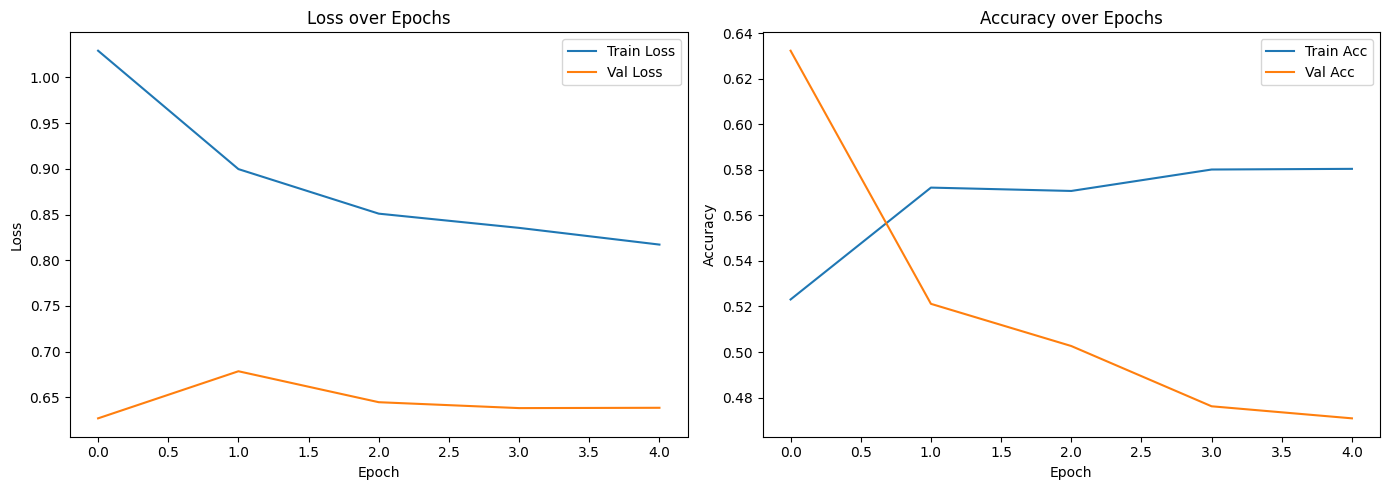

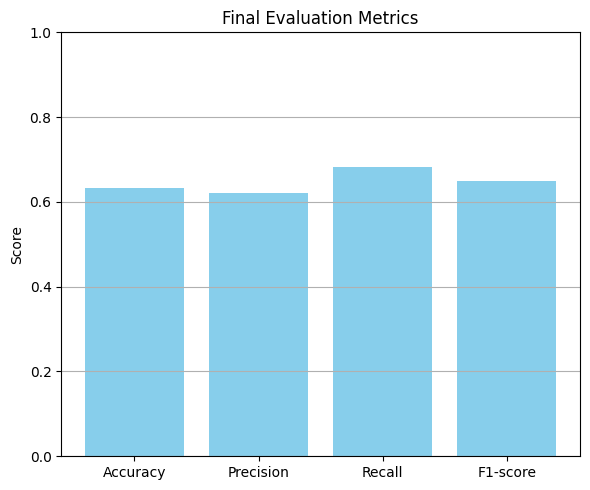

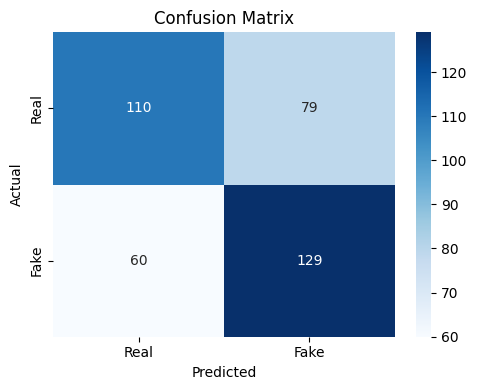

In [ ]:
# 90/10 class weights
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load Data from saved_features directory
print("\n[INFO] Loading feature vectors and labels from './saved_features'...")
data_dir = "./saved_features"
X = np.load(os.path.join(data_dir, "X_visual.npy"))
y = np.load(os.path.join(data_dir, "y_visual.npy"))
print(f"[OK] Data loaded. X shape: {X.shape}, y shape: {y.shape}")

# Train-Test Split (90% Train / 10% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
print(f"[OK] Train: {len(X_train)}, Test: {len(X_test)}")

# Manually Set Class Weights
class_weights = {0: 2.0, 1: 1.0}  # Boost Real class
print(f"[OK] Using Manual Class Weights: {class_weights}")

# Build MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(X.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])
print("[OK] Model compiled.")

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# Train Model
print("\n[INFO] Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# Evaluate
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n[RESULT] Evaluation Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\n[INFO] Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

# Loss & Accuracy Plots
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Metrics Summary Plot
plt.figure(figsize=(6, 5))
plt.bar(["Accuracy", "Precision", "Recall", "F1-score"],
        [accuracy, precision, recall, f1], color='skyblue')
plt.ylim(0, 1)
plt.title("Final Evaluation Metrics")
plt.ylabel("Score")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



In [ ]:
model.save("/content/drive/MyDrive/DeepFake Datasets/deepfake_mlp_model.h5")
print("[OK] Model saved to Drive.")

[OK] Model saved to Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q streamlit pyngrok ffmpeg-python rich==13.7.1 packaging==23.2 jedi==0.19.1 tensorflow==2.18.0 --force-reinstall
!ngrok config add-authtoken 2xH0JoVt4m22WCYuk7nJ7wjZN0t_65jCGEnZPzxFScUtodrPm
!rm -rf ~/.keras/models/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.0 which is incompatible.
google-colab 1.0.0 requires requests==2.32.3, but you have requests 2.32.4 which is incompatible.
google-colab 1.0.0 requires tornado==6.4.2, but you have tornado 6.5.1 which is incompatible.
google-auth 2.38.0 requires cachetools<6.0,>=2.0.0, but you have cachetools 6.1.0 which is incompatible.
cudf-cu12 25.2.1 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
cudf-cu12 25.2.1 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 20.0.0 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
pylibcudf-cu12 25.2.1 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you hav

In [ ]:
from tensorflow.keras.applications import MobileNetV2
mobilenet = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
print("MobileNetV2 loaded and cached.")

/tmp/ipython-input-12-2555241347.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded and cached.


In [ ]:
streamlit_code = """
import streamlit as st
import os
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from PIL import Image

# -------------------------------------------------------------------
# Paths and folders
# -------------------------------------------------------------------
BASE_PATH     = "/content/drive/MyDrive/DeepFake Datasets"
MODEL_PATH    = os.path.join(BASE_PATH, "deepfake_mlp_model.h5")
UPLOAD_FOLDER = os.path.join(BASE_PATH, "WebMedia", "upload")
FRAME_FOLDER  = os.path.join(BASE_PATH, "WebMedia", "frames")

os.makedirs(UPLOAD_FOLDER, exist_ok=True)
os.makedirs(FRAME_FOLDER,  exist_ok=True)

# -------------------------------------------------------------------
# Load model and feature extractor
# -------------------------------------------------------------------
model = load_model(MODEL_PATH)
feature_extractor = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")

# -------------------------------------------------------------------
# Streamlit configuration
# -------------------------------------------------------------------
st.set_page_config(page_title="DeepFake Detection", layout="centered")
st.title("DeepFake Detection Tool")

# Resource links under title
col1, col2, col3 = st.columns([5, 3, 3])
with col2:
    st.markdown(
        "[DeepFake Samples for Testing](https://drive.google.com/drive/folders/1J5p4AW3UNRRAVOfmGTYnHW7M8dZBd_Vv?usp=share_link)",
        unsafe_allow_html=True
    )
with col3:
    st.markdown(
        "[Real Samples for Testing](https://drive.google.com/drive/folders/1uSYEwZ8RvcTf2eJNwFsH9whntNabEZGF?usp=share_link)",
        unsafe_allow_html=True
    )

st.markdown("Upload a short **.mp4** video for DeepFake analysis.")

# -------------------------------------------------------------------
# File uploader
# -------------------------------------------------------------------
uploaded_file = st.file_uploader("Choose an MP4 video", type=["mp4"])

if uploaded_file is not None:
    video_path = os.path.join(UPLOAD_FOLDER, uploaded_file.name)
    with open(video_path, "wb") as f:
        f.write(uploaded_file.read())

    st.video(video_path)
    st.info("Video uploaded successfully. Extracting frames...")

    for fname in os.listdir(FRAME_FOLDER):
        os.remove(os.path.join(FRAME_FOLDER, fname))

    cap   = cv2.VideoCapture(video_path)
    fps   = int(cap.get(cv2.CAP_PROP_FPS)) or 1
    count = saved = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if count % fps == 0:
            frame_path = os.path.join(FRAME_FOLDER, f"frame_{saved:04d}.jpg")
            cv2.imwrite(frame_path, frame)
            saved += 1
        count += 1
    cap.release()

    frame_files = sorted(f for f in os.listdir(FRAME_FOLDER) if f.endswith(".jpg"))

    if not frame_files:
        st.error("No frames were extracted. Please try another video.")
    else:
        st.success(f"Extracted {len(frame_files)} frames.")
        st.subheader("Sample Frames")
        cols = st.columns(5)
        for i, frame_name in enumerate(frame_files[:5]):
            img_path = os.path.join(FRAME_FOLDER, frame_name)
            cols[i % 5].image(Image.open(img_path),
                              caption=f"Frame {i + 1}",
                              use_column_width=True)

        st.info("Running DeepFake prediction...")
        features = []
        for frame_name in frame_files[:5]:
            img_path = os.path.join(FRAME_FOLDER, frame_name)
            img = image.load_img(img_path, target_size=(224, 224))
            x   = preprocess_input(np.expand_dims(image.img_to_array(img), axis=0))
            feat = feature_extractor.predict(x, verbose=0)
            features.append(feat[0])

        avg_feature = np.mean(features, axis=0).reshape(1, -1)
        prediction  = model.predict(avg_feature, verbose=0)[0][0]

        st.subheader("Prediction Result")
        confidence = prediction if prediction > 0.5 else 1 - prediction
        label      = "FAKE" if prediction > 0.5 else "REAL"

        st.markdown(f"Prediction: **{label}**")
        st.markdown(f"Confidence Score: {confidence:.2f}")
else:
    st.warning("Please upload an MP4 video to continue.")
"""

# -------------------------------------------------------------------
# Save the script
# -------------------------------------------------------------------
with open("app.py", "w") as f:
    f.write(streamlit_code)

print("Streamlit app saved as app.py.")

Streamlit app saved as app.py.


In [ ]:
from pyngrok import ngrok
import time
import os, signal, subprocess

# 1. Kill any prior ngrok tunnels
ngrok.kill()

# 2. Start (or restart) Streamlit in the background
!streamlit run app.py --server.port 8501 &>/content/logs.txt &
time.sleep(20)                        # give Streamlit time to come up

# 3. Open a public tunnel
public_url = ngrok.connect(8501)      # or ngrok.connect(addr=8501, bind_tls=True)
print(f"Streamlit app is live at: {public_url}")

Streamlit app is live at: NgrokTunnel: "https://7150-34-57-85-197.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
!cat /content/logs.txt | tail -n 50



2025-06-03 20:28:55.283 Port 8501 is already in use
